<a href="https://colab.research.google.com/github/pink3y3/link_prediction-citation_network/blob/main/citation_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CORA DATASET - EXPLORATIVE DATA ANALYSIS

Understanding the dataset before building models on it.

Here, our dataset is a network.

EDA is the process of summarising and visualising the main characteristics of a dataset to understand its structure, identify patterns and make good modeling decisions


In [1]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.0 MB/s eta 0:00:00


In [3]:
# Load dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print(f"Nodes:           {data.num_nodes}") #papers
print(f"Edges:           {data.num_edges}") #links
print(f"Node features:   {data.num_node_features}") #paper features
print(f"Classes:         {dataset.num_classes}") #node classification (7)
print(f"Is undirected:   {data.is_undirected()}")

Processing...


Nodes:           2708
Edges:           10556
Node features:   1433
Classes:         7
Is undirected:   True


Done!


In [2]:
import torch
import torch_geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [4]:
print(data)
# node features shape
print(f"Feature matrix shape: {data.x.shape}") # 2708 nodes(papers), each with 1433 features
# edge connections
print(f"Edge index shape:     {data.edge_index.shape}") # 2 rows: source nodes and target nodes
# Node labels (paper topic)
print(f"Labels shape:         {data.y.shape}")
# one class label per node

# Train/val/test nodes
print(f"\nTraining nodes:   {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes:       {data.test_mask.sum().item()}")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Feature matrix shape: torch.Size([2708, 1433])
Edge index shape:     torch.Size([2, 10556])
Labels shape:         torch.Size([2708])

Training nodes:   140
Validation nodes: 500
Test nodes:       1000


In [5]:
#first 5 edges
print("Source nodes:", data.edge_index[0][:5].tolist()) #convert tensor into a list
print("Target nodes:", data.edge_index[1][:5].tolist())

#first node's features (1433 values)
print("\nNODE 0 FEATURES")
print(f"Feature vector length: {len(data.x[0])}") #1433 values
print(f"Non-zero features:     {(data.x[0] != 0).sum().item()}") #creates a boolean tensor - counts to number of trues
print(f"First 10 values:       {data.x[0][:10].tolist()}") #take the first 10 values of node 0's features

# Class labels
print("\nCLASS DISTRIBUTION") #tells if dataset is imbalanced
for i in range(dataset.num_classes):
    count = (data.y == i).sum().item()
    print(f"Class {i}: {count} papers")

Source nodes: [633, 1862, 2582, 2, 652]
Target nodes: [0, 0, 0, 1, 1]

NODE 0 FEATURES
Feature vector length: 1433
Non-zero features:     9
First 10 values:       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

CLASS DISTRIBUTION
Class 0: 351 papers
Class 1: 217 papers
Class 2: 418 papers
Class 3: 818 papers
Class 4: 426 papers
Class 5: 298 papers
Class 6: 180 papers


DEGREE STATISTICS
Average degree:  3.90
Max degree:      168
Min degree:      1
Median degree:   3.00


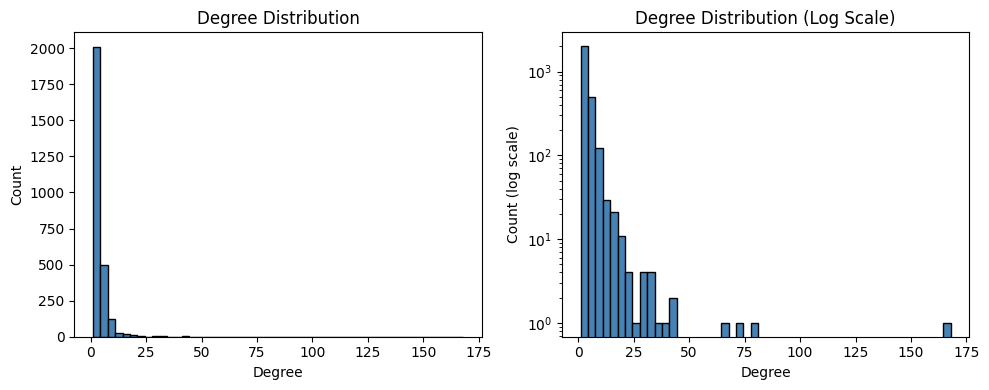

In [6]:
#convert to NetworkX for analysis
G = to_networkx(data, to_undirected=True)

#calculate degrees
degrees = [d for n, d in G.degree()]

print("DEGREE STATISTICS")
print(f"Average degree:  {np.mean(degrees):.2f}")
print(f"Max degree:      {np.max(degrees)}")
print(f"Min degree:      {np.min(degrees)}")
print(f"Median degree:   {np.median(degrees):.2f}")

# Plot degree distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Degree Distribution')

plt.subplot(1, 2, 2)
plt.hist(degrees, bins=50, color='steelblue',
         edgecolor='black', log=True)
plt.xlabel('Degree')
plt.ylabel('Count (log scale)')
plt.title('Degree Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150)
plt.show()

INference from above graph -

Huge spike from degree 1-5 indicates that most papers cite only a few other papers. The network is sparse.

Distribution has a long tail. Few papers have higher degrees(>20) and they are called hub nodes(highly influential papers).

Log-scale graph almost forms a straight declining line which suggests a power-law distribution (small values occur frequently) or a scale-free network (most nodes have very very connnections and a few nodes have huge number of connections)

Graph statistics terms

1. Graph Density - how many edges actually exist compared to the max possible number of edges

2. Average Clustering Co-efficient - if two of my neighbors are connected to me, how likely aere they to also be connected to each other

3. Connected Components - a group of nodes where every node can be reached from every other node

In [7]:
print("Graph Statistics")
# Ddensity
den = nx.density(G)
print(f"Graph density:          {den:.6f}")
print(f"Very sparse (close to 0 = sparse)")

#average clustering coefficient
avg_clust = nx.average_clustering(G)
print(f"\nAvg clustering coeff:   {avg_clust:.4f}") #how tight knit the graph is

#connected components
con_comp = nx.number_connected_components(G)
print(f"\nConnected components:   {con_comp}")


Graph Statistics
Graph density:          0.001440
Very sparse (close to 0 = sparse)

Avg clustering coeff:   0.2407

Connected components:   78


In [8]:
print("ImPLICATIONS FOR LINK PREDICTION")
print()
print(f"1. Sparsity: {nx.density(G):.6f}") #most possible connected(edges) in the graph don't exist
print("Most node pairs have NO edge. Ngeative sampling will be easy")
print()
print(f"2. Avg degree: {np.mean(degrees):.2f}")
print("Most papers cite approximately 4 others")
print()
print(f"3. Features: 1433 per node")
print("Word presence in paper title/abstract. GNNs can use this, heuristics cannot us this")
print()
print(f"4. 7 classes (paper topics)")
print("Papers in same class likely cite each other. Good signal for link prediction")

ImPLICATIONS FOR LINK PREDICTION

1. Sparsity: 0.001440
Most node pairs have NO edge. Ngeative sampling will be easy

2. Avg degree: 3.90
Most papers cite approximately 4 others

3. Features: 1433 per node
Word presence in paper title/abstract. GNNs can use this, heuristics cannot us this

4. 7 classes (paper topics)
Papers in same class likely cite each other. Good signal for link prediction
